In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(os.getcwd())
os.chdir("../../soge-home/projects/mistral/mans4178/schools")
print(os.getcwd())

/hn01-home/mans4178
/lustre/soge1/projects/mistral/mans4178/schools


In [3]:
ISO3 = "TZA"

### Prepare survey data

Household survey source:
https://microdata.worldbank.org/index.php/catalog/5639/

In [4]:
survey_c = pd.read_csv("validation/survey_data/TZA/TZA_2020_NPS-R5_v02_M_CSV/hh_sec_c.csv")

In [5]:
print("Number of survey responses: "+str(len(survey_c)))
print("Number of non-empty responses: "+str(survey_c.hh_c15.count()))

Number of survey responses: 23592
Number of non-empty responses: 6074


In [6]:
# Filter empty responses
survey_c = survey_c[survey_c["hh_c15"].notnull()]

In [7]:
# Add household weights
survey_a = pd.read_csv("validation/survey_data/TZA/TZA_2020_NPS-R5_v02_M_CSV/hh_sec_a.csv")
survey = survey_c.merge(survey_a[["y5_hhid","y5_crossweight"]],
             on="y5_hhid",
             how="left")

In [8]:
# Filter not tertiary
survey = survey[(survey['hh_c09'] >= 12) & (survey['hh_c09'] <=33)]

In [9]:
print("Number of non-empty, primary and secondary schools only responses: "+str(survey.hh_c15.count()))

Number of non-empty, primary and secondary schools only responses: 5392


In [10]:
# Filter only walking 
survey = survey[survey["hh_c14"]==1]

# Filter only not-walking 
# survey = survey[survey["hh_c14"]!=1]

In [11]:
print("Number of non-empty, primary and secondary schools, walking only responses: "+str(survey.hh_c15.count()))

Number of non-empty, primary and secondary schools, walking only responses: 4876


In [12]:
tt_col = "hh_c15"
weight_col = "y5_crossweight"

### Import model data

In [13]:
df_summary_1km = pd.read_csv(
    f"model_1km/outputs/jrc/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

df_summary_90m = pd.read_csv(
    f"model_90m/outputs/jrcwalking/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

### Plot distributions (nationally)

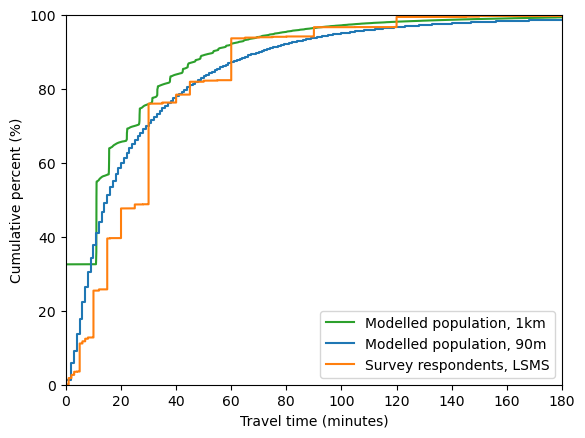

In [14]:
fig, ax = plt.subplots()
sns.ecdfplot(data=df_summary_1km, x="traveltime", weights="pop", stat="percent", label="Modelled population, 1km", color=sns.color_palette()[2])
sns.ecdfplot(data=df_summary_90m, x="traveltime", weights="pop", stat="percent", label="Modelled population, 90m", color=sns.color_palette()[0])
sns.ecdfplot(data=survey, x=tt_col, weights=weight_col, stat="percent", label="Survey respondents, LSMS", color=sns.color_palette()[1])
ax.set_xlim([0, 180])
ax.set_ylim([0, 100])
ax.set_xlabel("Travel time (minutes)")
ax.set_ylabel("Cumulative percent (%)")
ax.legend(loc ='lower right')
plt.show()

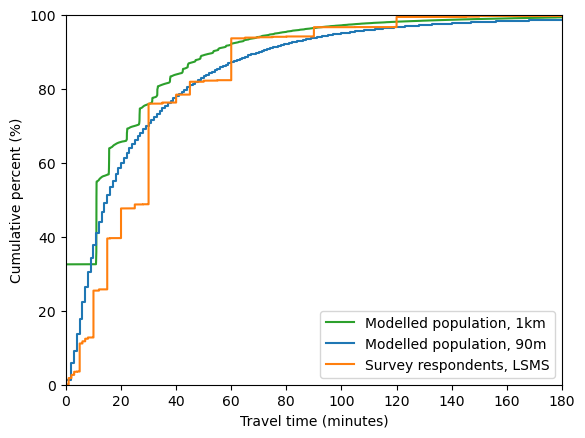

In [15]:
fig, ax = plt.subplots()
sns.ecdfplot(data=df_summary_1km, x="traveltime", weights="pop", stat="percent", label="Modelled population, 1km", color=sns.color_palette()[2])
sns.ecdfplot(data=df_summary_90m, x="traveltime", weights="pop", stat="percent", label="Modelled population, 90m", color=sns.color_palette()[0])
sns.ecdfplot(data=survey, x=tt_col, weights=weight_col, stat="percent", label="Survey respondents, LSMS", color=sns.color_palette()[1])
ax.set_xlim([0, 180])
ax.set_ylim([0, 100])
ax.set_xlabel("Travel time (minutes)")
ax.set_ylabel("Cumulative percent (%)")
ax.legend(loc ='lower right')
plt.show()

### Compare CDFs (areas between curves)

In [16]:
import validation.ipynb.compare_cdfs as compare_cdfs

In [17]:
metrics_90m = compare_cdfs.compare_cdfs(df_summary_90m,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [18]:
metrics_1km = compare_cdfs.compare_cdfs(df_summary_1km,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [20]:
table = pd.DataFrame([metrics_90m, metrics_1km], index=["90m model", "1km model"])
table = table.reset_index().rename(columns={"index": "model"})
table.insert(0, "ISO3", ISO3)
table.to_csv(f"validation/model_comp/cdf_metrics__{ISO3}.csv")
table

,ISO3,model,A+,A-,Aabs,A+_norm,A-_norm,Aabs_norm
0,TZA,90m model,4.123368,2.015406,6.138775,0.034361,0.016795,0.051156
1,TZA,1km model,8.153495,0.143082,8.296577,0.067946,0.001192,0.069138
